In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')
import zipfile

In [2]:
# Extract titles.csv.zip
with zipfile.ZipFile('C:\\Users\\SUMIT\\Downloads\\titles.csv.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

# Extract credits.csv.zip
with zipfile.ZipFile('C:\\Users\\SUMIT\\Downloads\\credits.csv.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')


In [3]:
# Load data
data1 = pd.read_csv('C:\\Users\\SUMIT\\Downloads\\titles.csv.zip')
data2 = pd.read_csv('C:\\Users\\SUMIT\\Downloads\\credits.csv.zip')

In [4]:
# Data Wrangling
data1.columns
data2.columns
data = pd.merge(data1,data2, on = 'id')

data.shape
data.columns
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124347 entries, 0 to 124346
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    124347 non-null  object 
 1   title                 124347 non-null  object 
 2   type                  124347 non-null  object 
 3   description           124256 non-null  object 
 4   release_year          124347 non-null  int64  
 5   age_certification     56707 non-null   object 
 6   runtime               124347 non-null  int64  
 7   genres                124347 non-null  object 
 8   production_countries  124347 non-null  object 
 9   seasons               8153 non-null    float64
 10  imdb_id               119044 non-null  object 
 11  imdb_score            118296 non-null  float64
 12  imdb_votes            118272 non-null  float64
 13  tmdb_popularity       124332 non-null  float64
 14  tmdb_score            114082 non-null  float64
 15  

In [5]:
# check for null values
data.isnull().sum()

# drop null values in description column
data.dropna(subset = ['description'], inplace = True)
# mode of age_certification
data['age_certification'].mode()[0]
# replace all null values of age_certification with mode
data['age_certification'].fillna(data['age_certification'].mode()[0],inplace=True)
data.isnull().sum()

data.dropna(subset = ['imdb_id'], inplace=True)
data.isnull().sum()

round(data['imdb_score'].mean(), 1)

np.float64(6.0)

In [6]:
# replacing all values in imdb_score with mean of imdb_score
data['imdb_score'].fillna(round(data['imdb_score'].mean(), 1), inplace = True)

data['imdb_votes'].fillna(0, inplace=True)
data.isnull().sum()


# mean of tmdb_popularity
round(data['tmdb_popularity'].mean(),2)
# replace null values in tmdb_popularity column with mean
data['tmdb_popularity'].fillna(round(data['tmdb_popularity'].mean(), 2), inplace = True)

# mean of the tmdb_score
round(data['tmdb_score'].mean(),1)
# replace null values in tmdb_score column with mean
data['tmdb_score'].fillna(round(data['tmdb_score'].mean(), 1), inplace = True)

data['character'].fillna('unknown', inplace=True)
data.isnull().sum()
data.shape

data.duplicated().sum()
data.drop_duplicates(inplace = True)
data.duplicated().sum()
data.dtypes
data.describe()


,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id
count,118854.000000,118854.000000,7400.000000,118854.000000,1.188540e+05,118854.000000,118854.000000,1.188540e+05
mean,1995.694592,96.054453,2.464865,5.968800,2.312887e+04,10.334860,5.997704,3.976869e+05
std,28.010517,29.798646,3.253967,1.238147,8.819975e+04,40.786345,1.252196,5.549632e+05
min,1912.000000,1.000000,1.000000,1.100000,0.000000e+00,0.000164,0.800000,1.000000e+00
25%,1980.000000,83.000000,1.000000,5.200000,2.790000e+02,1.917000,5.400000,3.821300e+04
50%,2009.000000,94.000000,1.000000,6.000000,1.227000e+03,3.960000,6.000000,1.323810e+05
75%,2017.000000,109.000000,3.000000,6.800000,7.040000e+03,8.924000,6.800000,5.633935e+05
max,2022.000000,328.000000,49.000000,9.900000,1.133692e+06,1437.906000,10.000000,2.371153e+06


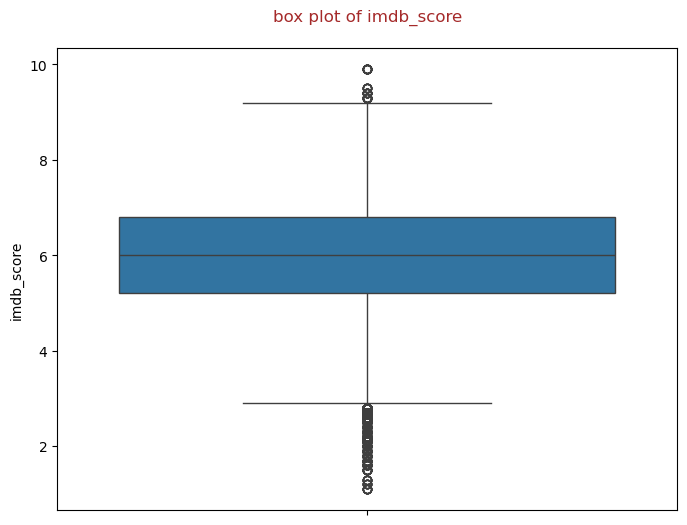

In [7]:
# univariate analysis
data
plt.figure(figsize = (8,6))
sns.boxplot(data = data, y = 'imdb_score')
plt.title('box plot of imdb_score\n',color = 'brown')
plt.show()

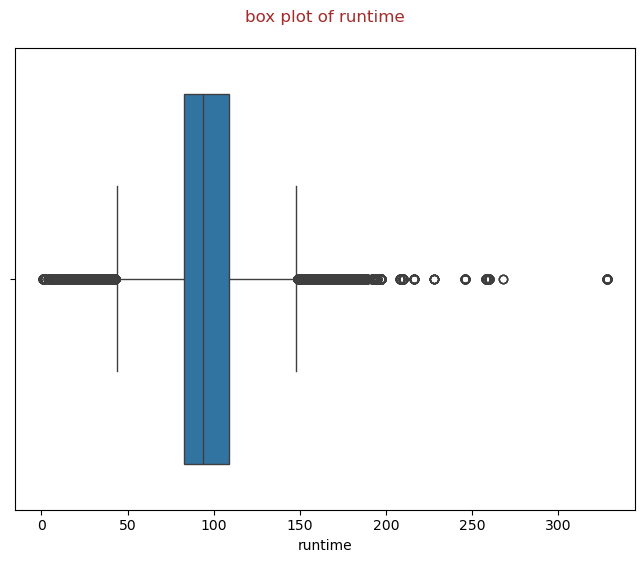

In [8]:
# box plot of runtime
plt.figure(figsize = (8,6))
sns.boxplot(data = data, x = 'runtime')
plt.title('box plot of runtime\n',color = 'brown')
plt.show()

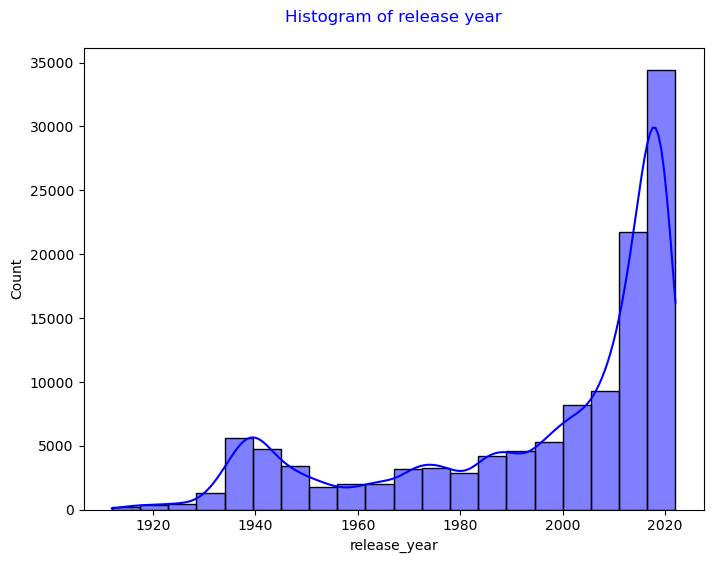

In [9]:
# Histogram of release_year
plt.figure(figsize = (8,6))
sns.histplot(data = data, x = 'release_year', bins = 20 ,color = 'blue', kde=True)
plt.title('Histogram of release year\n',color = 'blue')
plt.show()

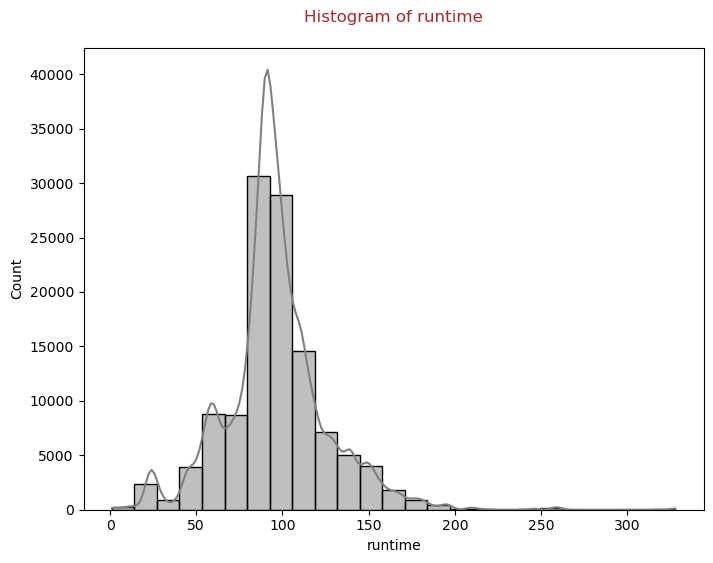

In [10]:
# Histogram of runtime
plt.figure(figsize = (8,6))
sns.histplot(data = data, x = 'runtime', bins = 25 ,color = 'grey', kde=True)
plt.title('Histogram of runtime\n',color = 'brown')
plt.show()

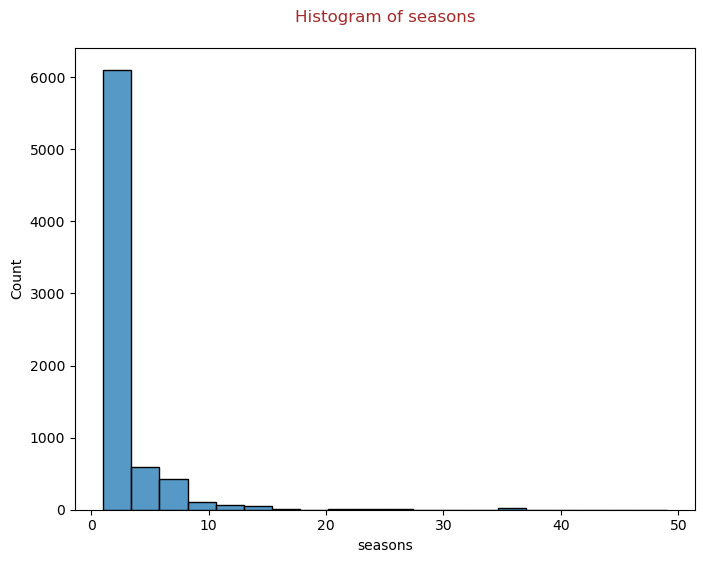

In [11]:
# Histogram of seasons
plt.figure(figsize = (8,6))
sns.histplot(data = data, x = 'seasons', bins = 20)
plt.title('Histogram of seasons\n',color = 'brown')
plt.show()

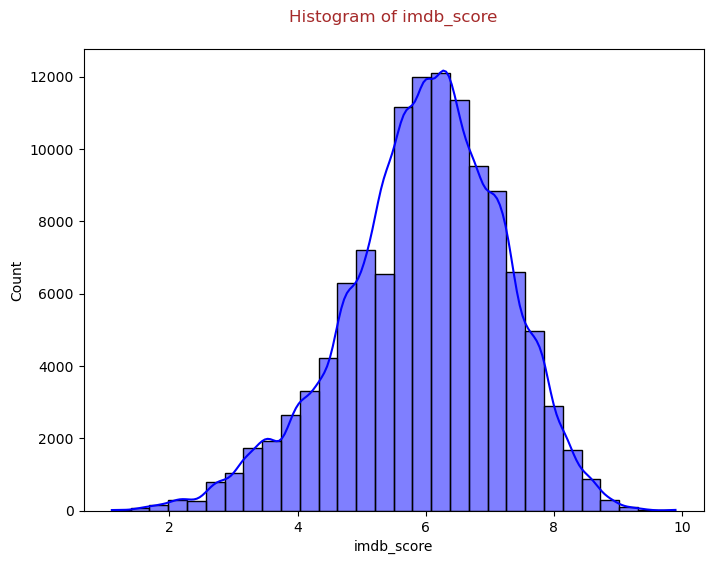

In [12]:
# Histogram of imdb_score
plt.figure(figsize = (8,6))
sns.histplot(data = data, x = 'imdb_score', bins = 30 ,color ='blue' ,kde = True)
plt.title('Histogram of imdb_score\n',color = 'brown')
plt.show()

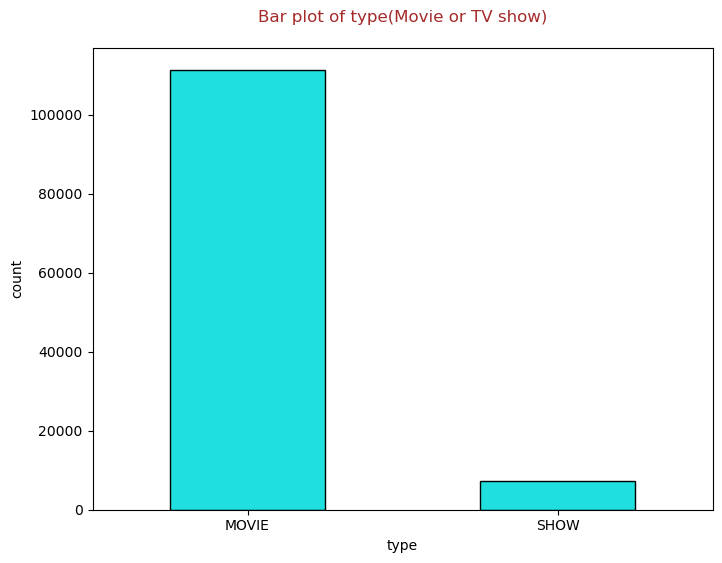

In [13]:
# Bar plot of types(Movie or TV show)
a = data.type.value_counts()
a

# Bar plot of type
plt.figure(figsize=(8,6))
sns.barplot(x = a.index, y= a.values, width=0.5, color='cyan', edgecolor = 'black')
plt.title('Bar plot of type(Movie or TV show)\n', color = 'brown')
plt.ylabel('count')
plt.show()

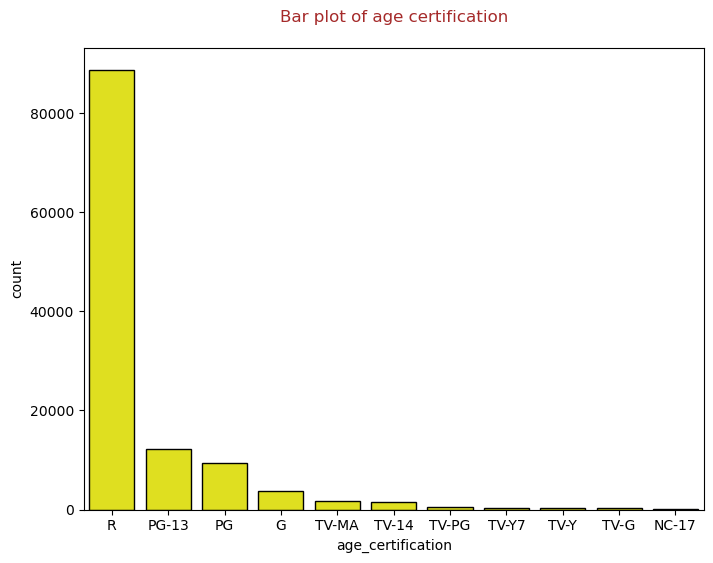

In [14]:
# Bar plot of age_certification
b = data.age_certification.value_counts()
b

# Bar plot of age_certification
plt.figure(figsize=(8,6))
sns.barplot(x = b.index, y= b.values, color='yellow', edgecolor = 'black')
plt.title('Bar plot of age certification\n', color = 'brown')
plt.ylabel('count')
plt.show()

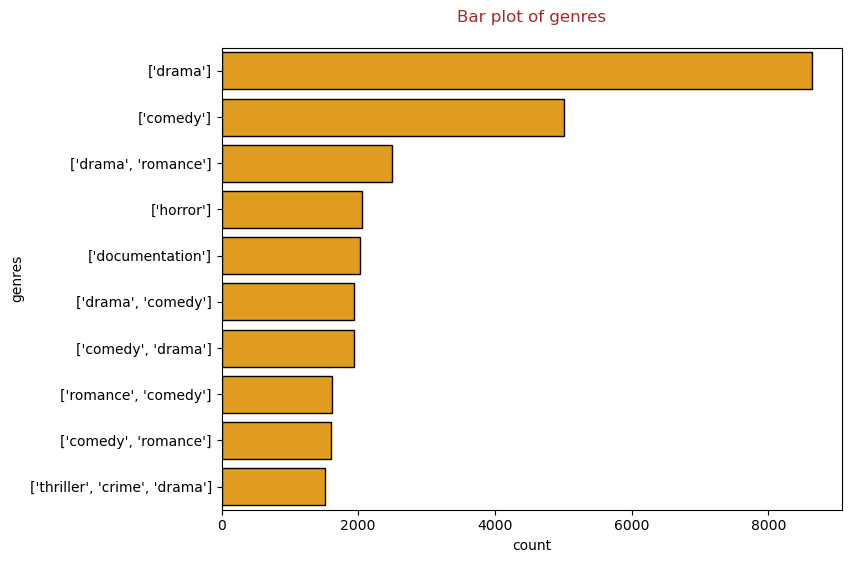

In [15]:
# Bar plot of games
genre_counts = data['genres'].value_counts()
a = genre_counts[genre_counts>1500]
a

# Bar plot of genres
plt.figure(figsize = (8,6))
sns.barplot(y = a.index, x = a.values, color = 'orange', edgecolor = 'black', orient='h')
plt.title('Bar plot of genres\n',color = 'brown')
plt.xlabel('count')
plt.show()

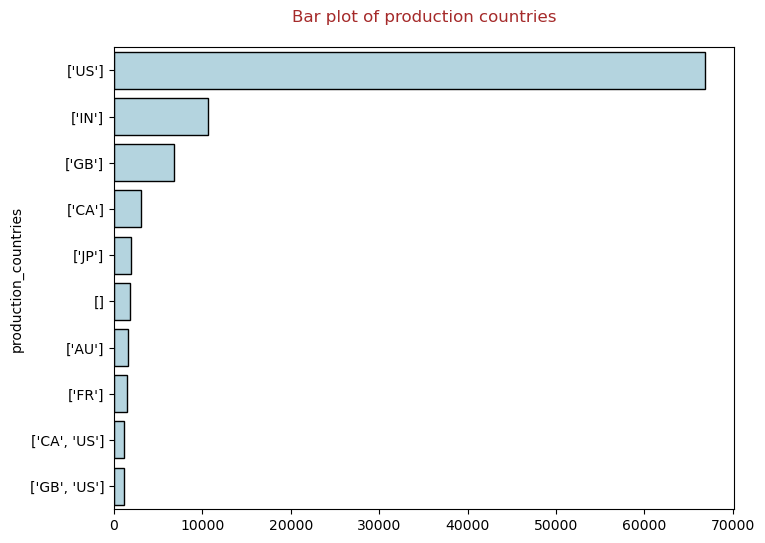

In [16]:
# Bar plot of production countries counts
prod_countries = data['production_countries'].value_counts()
countries = prod_countries[prod_countries>1000]
countries

# Bar plot of production countries
plt.figure(figsize=(8,6))
sns.barplot(x = countries.values, y = countries.index, orient='h', color = 'lightblue',edgecolor = 'black')
plt.title('Bar plot of production countries\n', color = 'brown')
plt.show()

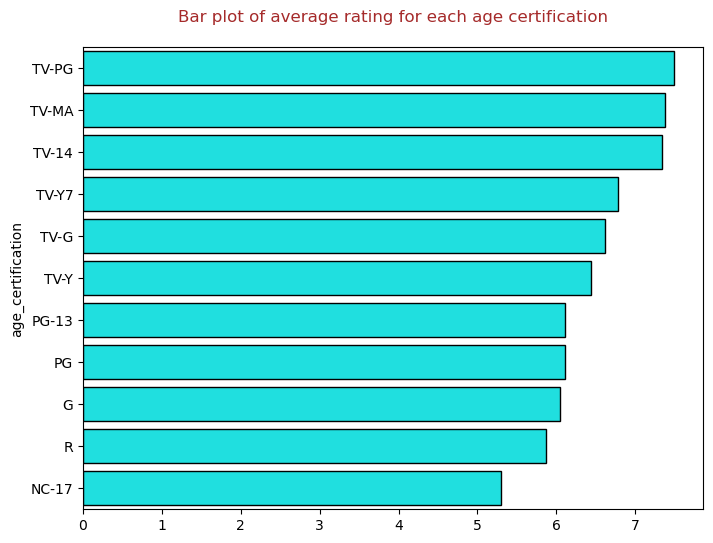

In [17]:
# Bar plot of average rating for each age certification
certification = data.groupby('age_certification')['imdb_score'].mean().sort_values(ascending=False)
certification

# Bar plot of average rating for each age certification
plt.figure(figsize =(8,6))
sns.barplot(x = certification.values, y = certification.index, edgecolor ='black',color='cyan')
plt.title('Bar plot of average rating for each age certification\n',color ='brown')
plt.show()


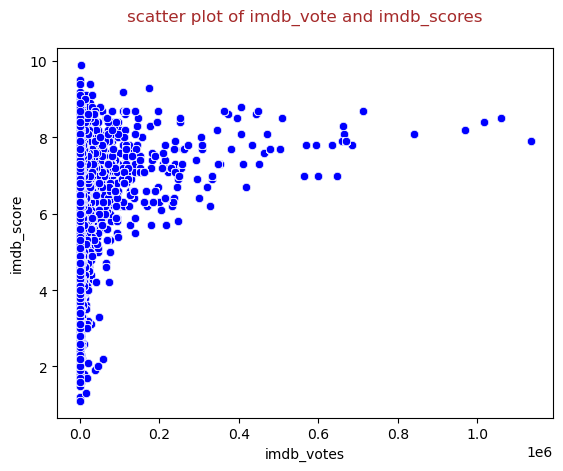

In [18]:
# Bivariate Analysis
# Scatter plot of imdb_vote and imdb_scores
sns.scatterplot(data = data, x = 'imdb_votes',y = 'imdb_score',color ='blue')
plt.title('scatter plot of imdb_vote and imdb_scores\n', color = 'brown')
plt.show()


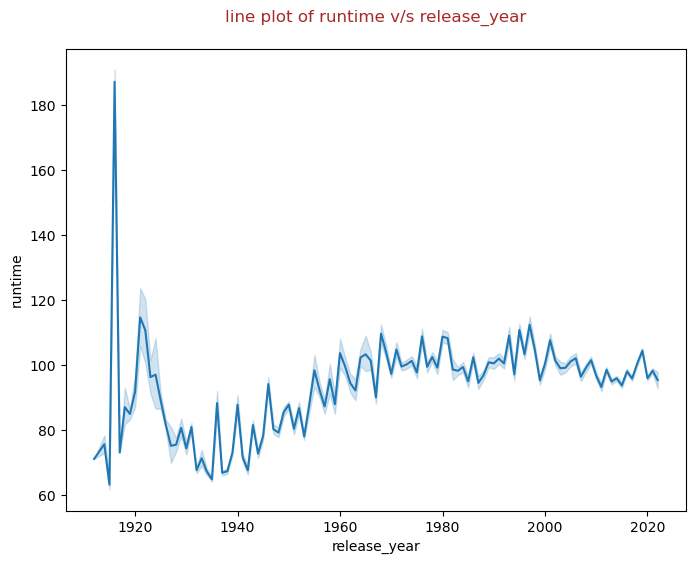

In [19]:
# line plot of runtime v/s release_year
plt.figure(figsize = (8,6))
sns.lineplot(data = data, y = 'runtime', x = 'release_year')
plt.title('line plot of runtime v/s release_year\n', color = 'brown')
plt.show()

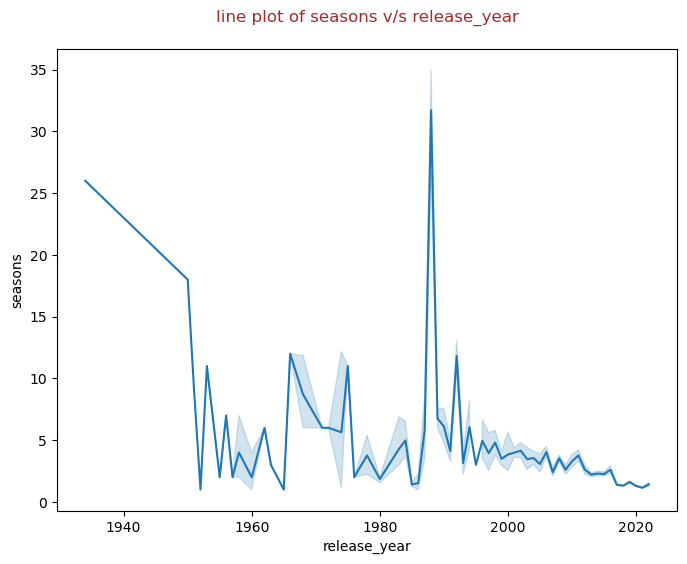

In [20]:
# line plot of seasons v/s release_year
plt.figure(figsize = (8,6))
sns.lineplot(data = data, y = 'seasons', x = 'release_year')
plt.title('line plot of seasons v/s release_year\n', color = 'brown')
plt.show()

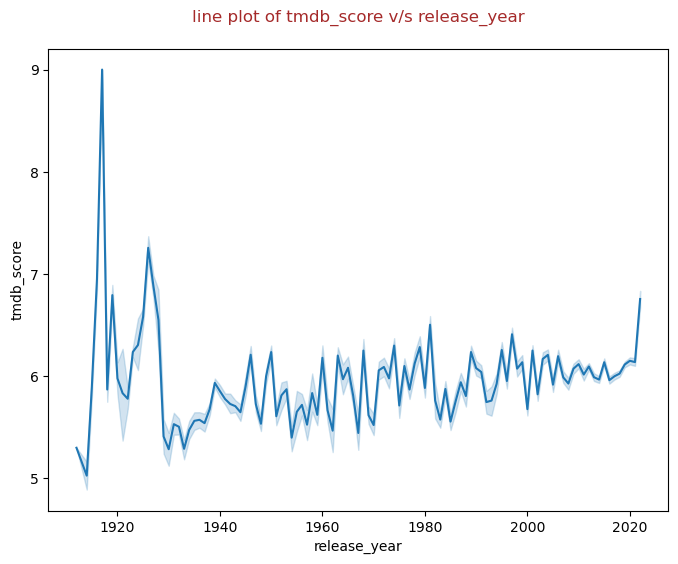

In [21]:
# line plot of tmdb_score v/s release_year
plt.figure(figsize = (8,6))
sns.lineplot(data = data, y = 'tmdb_score', x = 'release_year')
plt.title('line plot of tmdb_score v/s release_year\n', color = 'brown')
plt.show()

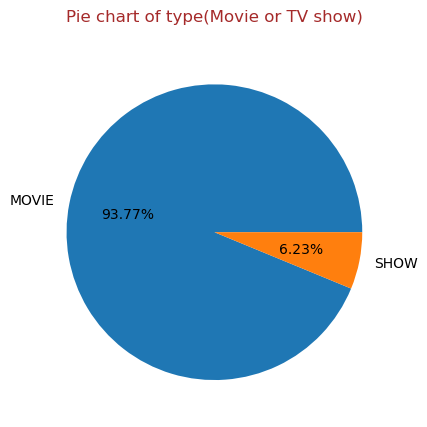

In [22]:
# Pie chart of type(Movie or TV show)
plt.pie(data['type'].value_counts(),labels=data['type'].value_counts().index,autopct = '%.2f%%')
plt.title('Pie chart of type(Movie or TV show)\n', color = 'brown')
plt.show()

In [23]:
# Pie chart of age_certification counts
a = data['age_certification'].value_counts()
a

# Pie chart of age_certification
import plotly.express as px
fig = px.pie(values  = a, names = a.index, title= 'pie chart of age certification')
fig.show()

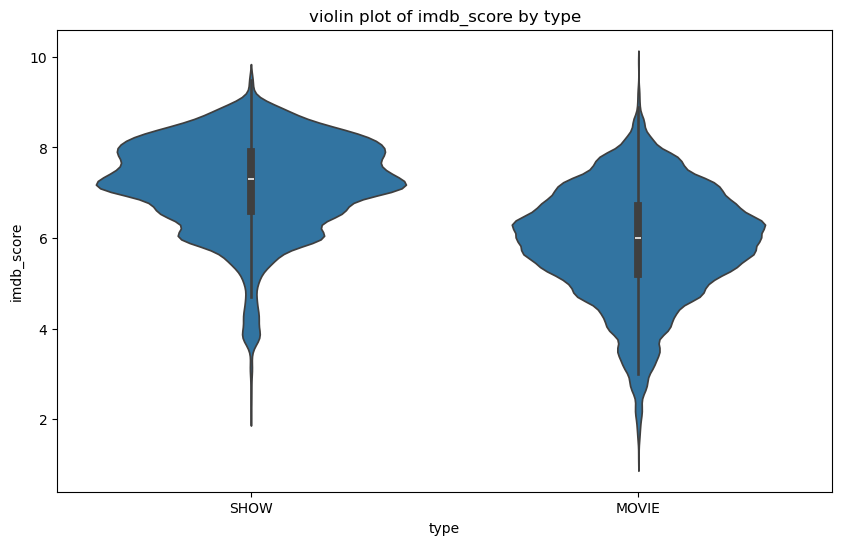

In [24]:
# violin plot of imbd_score by type
plt.figure(figsize=(10,6))
sns.violinplot(x='type', y='imdb_score', data = data)
plt.title('violin plot of imdb_score by type')
plt.show()


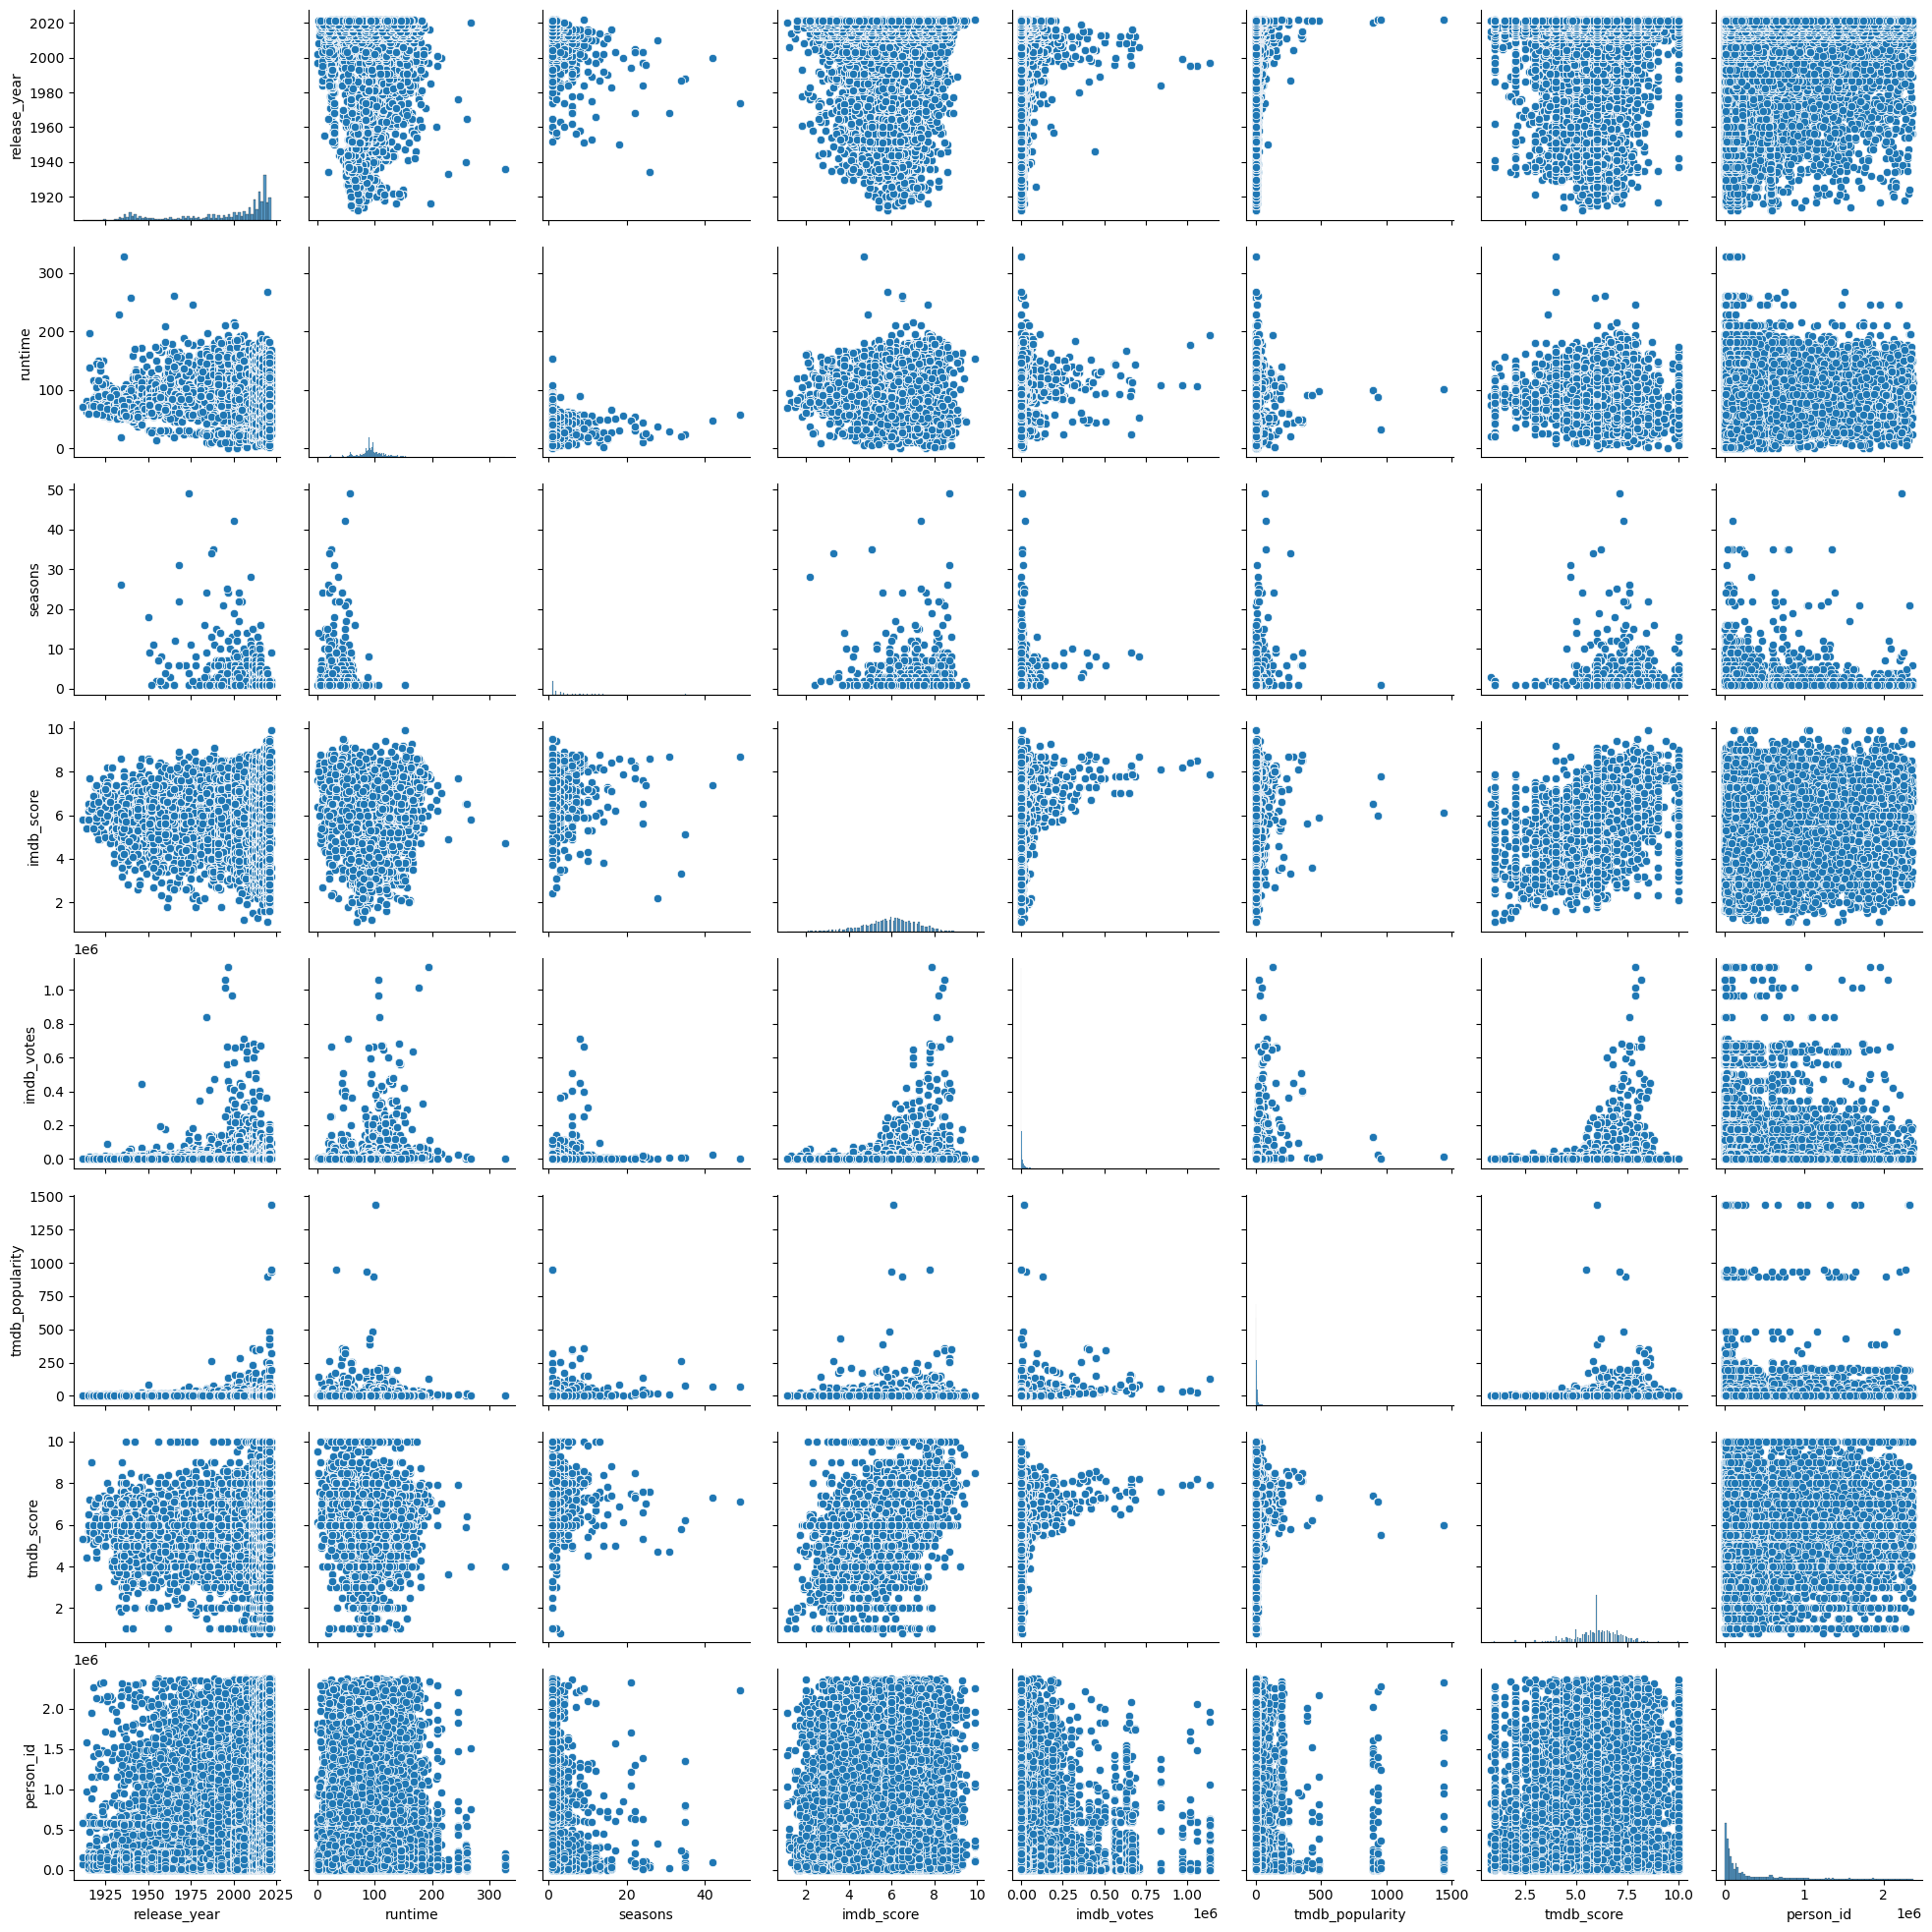

In [25]:
# Multivariable Analysis
# Pair plot
sns.pairplot(data)
plt.show()

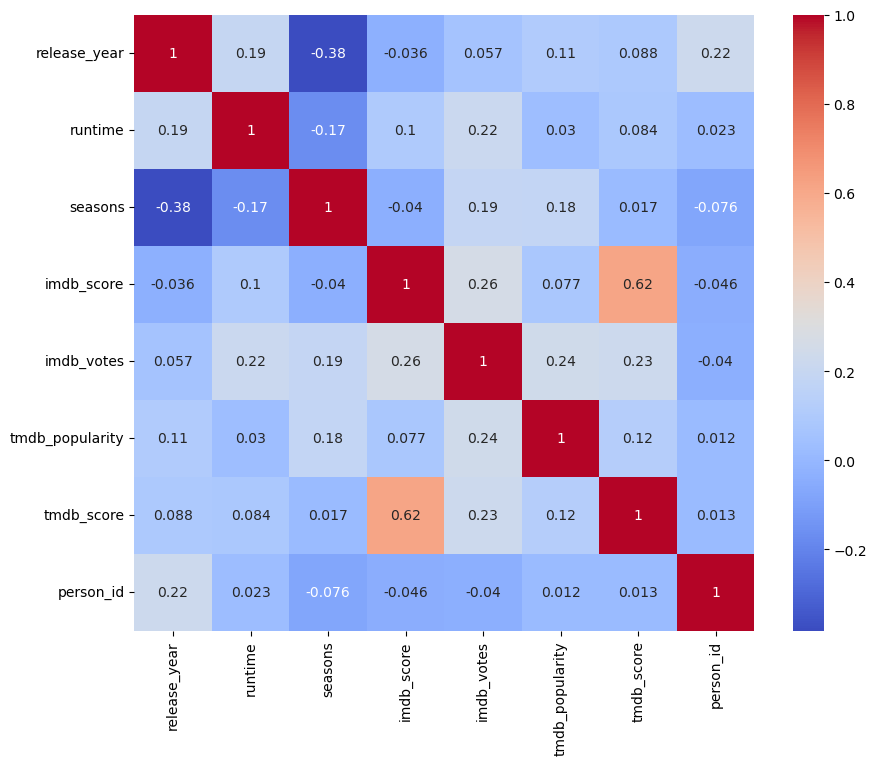

In [26]:
# HEATMAP
num_col = data.select_dtypes(include = ['int64','float64'])
#heatmap
plt.figure(figsize = (10,8))
sns.heatmap(num_col.corr(),annot = True, cmap = 'coolwarm')
plt.show()

In [27]:
# Hypothesis 1: IMDb Votes vs IMDb Score
from scipy.stats import pearsonr

# Clean data
df1 = data[['imdb_votes', 'imdb_score']].dropna()

corr, p_value = pearsonr(df1['imdb_votes'], df1['imdb_score'])

print("Correlation:", corr)
print("P-value:", p_value)

# Decision
if p_value < 0.05:
    print("Reject Null Hypothesis → Significant relationship exists")
else:
    print("Fail to Reject Null Hypothesis → No significant relationship")

Correlation: 0.26316367042009947
P-value: 0.0
Reject Null Hypothesis → Significant relationship exists


In [28]:
# Hypothesis 2: Movie vs TV Show Ratings
from scipy.stats import ttest_ind

# Separate groups
movie = data[data['type'] == 'MOVIE']['imdb_score'].dropna()
show = data[data['type'] == 'SHOW']['imdb_score'].dropna()

t_stat, p_value = ttest_ind(movie, show)

print("T-Statistic:", t_stat)
print("P-value:", p_value)

# Decision
if p_value < 0.05:
    print("Reject Null Hypothesis → Significant difference")
else:
    print("Fail to Reject Null Hypothesis → No significant difference")    


T-Statistic: -91.36248556993624
P-value: 0.0
Reject Null Hypothesis → Significant difference


In [29]:
# Hypothesis 3: Age Certification vs IMDb Score
from scipy.stats import f_oneway

# Get top certifications (to avoid noise)
top_cert = data['age_certification'].value_counts().head(5).index

groups = [
    data[data['age_certification'] == cert]['imdb_score'].dropna()
    for cert in top_cert
]

f_stat, p_value = f_oneway(*groups)

print("F-Statistic:", f_stat)
print("P-value:", p_value)

# Decision
if p_value < 0.05:
    print("Reject Null Hypothesis → Ratings differ across certifications")
else:
    print("Fail to Reject Null Hypothesis → No difference")

F-Statistic: 794.8000638946771
P-value: 0.0
Reject Null Hypothesis → Ratings differ across certifications


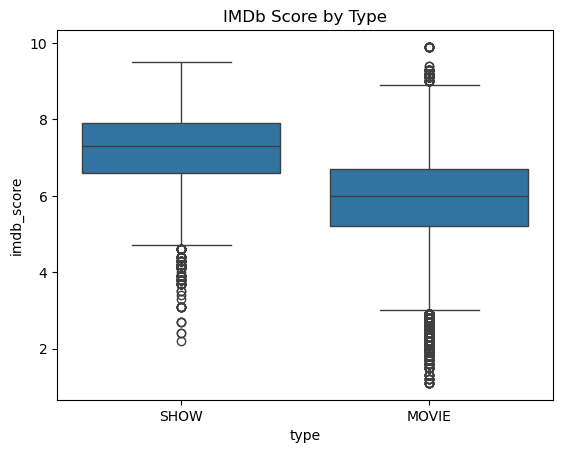

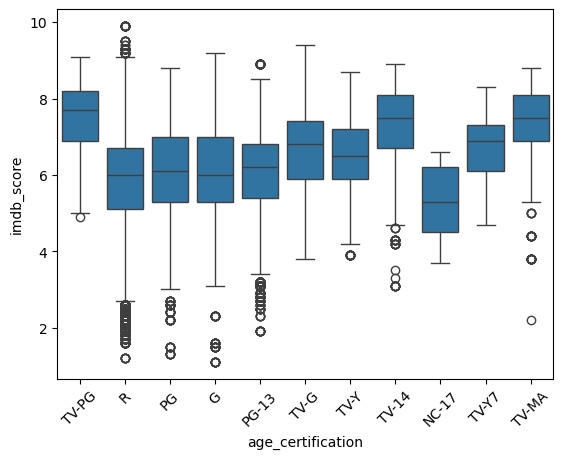

In [30]:
# Boxplot for type vs score
sns.boxplot(x='type', y='imdb_score', data=data)
plt.title("IMDb Score by Type")
plt.show()

# Boxplot for certification vs score
sns.boxplot(x='age_certification', y='imdb_score', data=data)
plt.xticks(rotation=45)
plt.show()        


In [31]:
# Handling Missing Values
# Fill missing values
data['age_certification'].fillna(data['age_certification'].mode()[0], inplace=True)
data['imdb_score'].fillna(round(data['imdb_score'].mean(),1), inplace=True)
data['imdb_votes'].fillna(0, inplace=True)
data['tmdb_popularity'].fillna(round(data['tmdb_popularity'].mean(),2), inplace=True)
data['tmdb_score'].fillna(round(data['tmdb_score'].mean(),1), inplace=True)
data['character'].fillna('unknown', inplace=True)


In [32]:
# Handling Outliers
# Removing outliers from runtime
Q1 = data['runtime'].quantile(0.25)
Q3 = data['runtime'].quantile(0.75)
IQR = Q3 - Q1
data = data[(data['runtime'] >= Q1 - 1.5*IQR) & (data['runtime'] <= Q3 + 1.5*IQR)]


In [33]:
# Categorical Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data['type'] = le.fit_transform(data['type'])
data['age_certification'] = le.fit_transform(data['age_certification'])


import ast
from sklearn.preprocessing import MultiLabelBinarizer

# Convert string to list
data['genres'] = data['genres'].apply(lambda x: ast.literal_eval(x) if isinstance(x,str) else [])

mlb = MultiLabelBinarizer()
genre_encoded = pd.DataFrame(mlb.fit_transform(data['genres']),
                             columns=mlb.classes_)

data = pd.concat([data, genre_encoded], axis=1)
data.drop('genres', axis=1, inplace=True)

# Textual data preprocessing 
# Ensure no null / non-string values
data['description'] = data['description'].fillna('').astype(str)

In [34]:
# Expand Contractions
import re

contractions_dict = {
    "can't": "cannot", "won't": "will not", "n't": " not",
    "'re": " are", "'s": " is", "'d": " would",
    "'ll": " will", "'ve": " have", "'m": " am"
}

def expand_contractions(text):
    try:
        pattern = re.compile('({})'.format('|'.join(contractions_dict.keys())), flags=re.IGNORECASE)
        
        def replace(match):
            return contractions_dict[match.group(0).lower()]
        
        return pattern.sub(replace, text)
    except:
        return ""

data['description'] = data['description'].apply(expand_contractions)

In [35]:
# Remove URLs
def remove_urls(text):
    try:
        return re.sub(r'http\S+|www\S+', '', text)
    except:
        return ""

data['description'] = data['description'].apply(remove_urls)


In [36]:
# Lowercase
def to_lower(text):
    try:
        return text.lower()
    except:
        return ""

data['description'] = data['description'].apply(to_lower)

In [37]:
# Remove Punctuation
import string

def remove_punctuation(text):
    try:
        return text.translate(str.maketrans('', '', string.punctuation))
    except:
        return ""

data['description'] = data['description'].apply(remove_punctuation)

In [38]:
# Remove Stopwords (NO ERROR VERSION)
from nltk.corpus import stopwords

# Run once
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    try:
        words = text.split()  # safer than word_tokenize
        words = [word for word in words if word not in stop_words]
        return " ".join(words)
    except:
        return ""

data['description'] = data['description'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SUMIT\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [39]:
# Remove Whitespaces
def remove_whitespace(text):
    try:
        return " ".join(str(text).split())
    except:
        return ""

data['description'] = data['description'].apply(remove_whitespace)


In [40]:
# Rephrase Text (Basic Cleaning)
def rephrase_text(text):
    try:
        return text.strip()
    except:
        return ""

data['description'] = data['description'].apply(rephrase_text)

In [41]:
# No nltk tokenizer (avoids errors)
data['tokens'] = data['description'].apply(lambda x: str(x).split())

# Text Normalization (LEMMATIZATION)
import nltk
nltk.download('wordnet')

from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_text(tokens):
    try:
        return [lemmatizer.lemmatize(word) for word in tokens]
    except:
        return []

data['tokens'] = data['tokens'].apply(lemmatize_text)


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\SUMIT\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [42]:
# Part of speech Tagging
nltk.download('averaged_perceptron_tagger')

from nltk import pos_tag

def pos_tagging(tokens):
    try:
        return pos_tag(tokens)
    except:
        return []

data['pos_tags'] = data['tokens'].apply(pos_tagging)

# Convert Tokens Back to Text
data['clean_text'] = data['tokens'].apply(lambda x: " ".join(x))

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\SUMIT\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [43]:
# Text Vectorization (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=300)

X_text = tfidf.fit_transform(data['clean_text']).toarray()

tfidf_df = pd.DataFrame(X_text, columns=tfidf.get_feature_names_out())

# Merge with main dataset
data = pd.concat([data.reset_index(drop=True), tfidf_df], axis=1)

In [44]:
# =========================================
# FEATURE MANIPULATION
# =========================================

# Create new features
data['total_score'] = (data['imdb_score'] + data['tmdb_score']) / 2
data['popularity_ratio'] = data['imdb_votes'] / (data['tmdb_popularity'] + 1)

# Remove highly correlated features
corr_matrix = data.corr(numeric_only=True)

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.85)]

data.drop(columns=to_drop, inplace=True, errors='ignore')

print("Dropped columns:", to_drop)

Dropped columns: ['comedy', 'crime', 'family', 'history', 'music', 'war', 'comedy', 'crime', 'family', 'history', 'music', 'war', 'total_score']


In [45]:
# =========================================
# FEATURE & TARGET SPLIT
# =========================================

# Ensure target exists
if 'imdb_score' not in data.columns:
    raise ValueError("Target column 'imdb_score' missing!")

y = data['imdb_score']
X = data.drop(columns=['imdb_score'], errors='ignore')


# =========================================
# CLEAN DATA BEFORE ML
# =========================================

X.replace([np.inf, -np.inf], np.nan, inplace=True)
X = X.fillna(0)
# =========================================
# COMPLETE SAFE CLEANING (NO ERRORS)
# =========================================

# Convert all possible columns to numeric
X = X.apply(pd.to_numeric, errors='coerce')

# Replace inf values
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaN
X = X.fillna(0)

# Final check
print("Remaining NaNs:", X.isnull().sum().sum())


Remaining NaNs: 0


In [46]:
# =========================================
# FEATURE SELECTION
# =========================================

import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer

# Assume X is a DataFrame and y is a Series
# Step 1: Drop rows where y is NaN
mask = ~pd.isna(y)
X = X[mask]
y = y[mask]

# Step 2: Impute missing values in X (if any)
imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)

# Step 3: Feature selection
selector = SelectKBest(score_func=f_classif, k=10)
X_new = selector.fit_transform(X, y)

print("Final shape:", X_new.shape)



Final shape: (108624, 10)


In [47]:
# =========================================
# DATA TRANSFORMATION
# =========================================

# Convert back to DataFrame for easy column handling
X = pd.DataFrame(X)

# Log transformation (safe)
X = np.log1p(X)


In [48]:
# =========================================
# TRAIN TEST SPLIT
# =========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


# =========================================
# SCALING
# =========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Train shape: (86899, 328)
Test shape: (21725, 328)


Original features: 328
Reduced features: 287


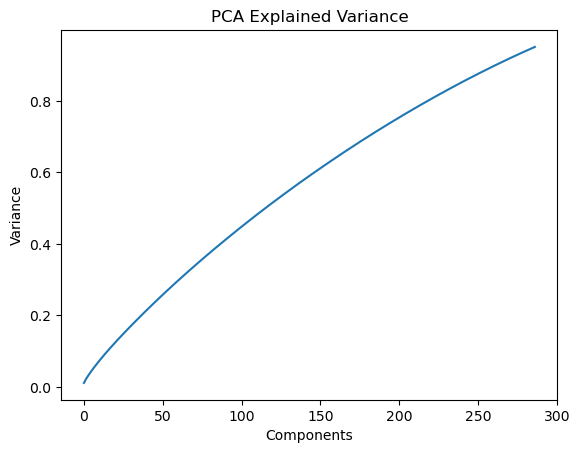

In [49]:
# =========================================
# PCA
# =========================================

from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

print("Original features:", X.shape[1])
print("Reduced features:", X_train.shape[1])


import matplotlib.pyplot as plt

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Components")
plt.ylabel("Variance")
plt.title("PCA Explained Variance")
plt.show()


In [50]:
# ===========================================
# MACHINE LEARNING MODEL 1: LINEAR REGRESSION
# ===========================================
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

lr = LinearRegression()

# Train
lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)

# Evaluation
print("----- Linear Regression -----")
print("R2 Score:", r2_score(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

----- Linear Regression -----
R2 Score: 0.450363968124475
RMSE: 0.8941578660735381


In [ ]:
# =========================================
# MODEL 2: DECISION TREE
# =========================================
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

# Train
dt.fit(X_train, y_train)

# Predict
y_pred_dt = dt.predict(X_test)

# Evaluation
print("\n----- Decision Tree -----")
print("R2 Score:", r2_score(y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))

In [ ]:
# Random Forest Machine learning model
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Smaller model for speed
rf = RandomForestRegressor(
    n_estimators=50,   # reduced for speed
    max_depth=10,
    random_state=42,
    n_jobs=-1          # use all CPU cores
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\n----- Random Forest -----")
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

In [ ]:
# Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=5,        # very fast
    cv=3,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

y_pred_best = best_model.predict(X_test)

print("\n----- Tuned Random Forest -----")
print("Best Params:", random_search.best_params_)
print("R2 Score:", r2_score(y_test, y_pred_best))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best)))

In [ ]:
# SAFE COMPARISON CHART
import matplotlib.pyplot as plt

models = []
scores = []

if 'y_pred_lr' in globals():
    models.append('Linear')
    scores.append(r2_score(y_test, y_pred_lr))

if 'y_pred_dt' in globals():
    models.append('Decision Tree')
    scores.append(r2_score(y_test, y_pred_dt))

models.append('Random Forest')
scores.append(r2_score(y_test, y_pred_rf))

plt.bar(models, scores)
plt.title("Model Comparison (R2 Score)")
plt.ylabel("Score")
plt.show()


In [ ]:
# FINAL DEBUG CHECKLIST
print(X_train.shape)
print(X_test.shape)
print(np.isnan(X_train).sum())   # should be 0